# Public Transportation Ridership Analysis

## Project Overview

This project analyzes public transportation ridership data from multiple transit agencies.

The goal is to clean, explore, and visualize ridership patterns using Python, Pandas, and data visualization techniques.

## Research Questions

1. Which transit agency has the highest total ridership?
2. How does ridership change over time?
3. How do ridership patterns differ between transit agencies?
4. What trends can be observed from the dataset?

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df = pd.read_csv("../data/raw/transit_ridership.csv")

In [92]:
df.head()

,Agency,Mode,Date,Week Number,Current Ridership,Year
0,WMATA Bus and Rail,Transit,06/05/2022,24,"266,000","2,022"
1,WMATA Bus and Rail,Transit,06/06/2022,24,"506,000","2,022"
2,WMATA Bus and Rail,Transit,06/07/2022,24,"536,000","2,022"
3,WMATA Bus and Rail,Transit,06/08/2022,24,"551,000","2,022"
4,WMATA Bus and Rail,Transit,06/09/2022,24,"539,000","2,022"


In [93]:
df.shape

(211, 6)

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Agency             211 non-null    str  
 1   Mode               211 non-null    str  
 2   Date               211 non-null    str  
 3   Week Number        211 non-null    int64
 4   Current Ridership  211 non-null    str  
 5   Year               211 non-null    str  
dtypes: int64(1), str(5)
memory usage: 10.0 KB


In [95]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['agency', 'mode', 'date', 'week_number', 'current_ridership', 'year'], dtype='str')

In [96]:
df["date"] = pd.to_datetime(df["date"])

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   agency             211 non-null    str           
 1   mode               211 non-null    str           
 2   date               211 non-null    datetime64[us]
 3   week_number        211 non-null    int64         
 4   current_ridership  211 non-null    str           
 5   year               211 non-null    str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 10.0 KB


In [98]:
df["current_ridership"] = (
    df["current_ridership"]
    .str.replace(",", "")
    .astype(int)
)

In [99]:
df["current_ridership"].dtype

dtype('int64')

In [100]:
df["year"] = (
    df["year"]
    .str.replace(",", "")
    .astype(int)
)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   agency             211 non-null    str           
 1   mode               211 non-null    str           
 2   date               211 non-null    datetime64[us]
 3   week_number        211 non-null    int64         
 4   current_ridership  211 non-null    int64         
 5   year               211 non-null    int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 10.0 KB


In [102]:
df.isnull().sum()

agency               0
mode                 0
date                 0
week_number          0
current_ridership    0
year                 0
dtype: int64

In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
df.describe()

,date,week_number,current_ridership,year
count,211,211.000000,2.110000e+02,211.0
mean,2022-07-22 21:36:40.947867,30.454976,1.010681e+06,2022.0
min,2022-06-05 00:00:00,24.000000,5.816900e+04,2022.0
25%,2022-07-06 00:00:00,28.000000,1.451505e+05,2022.0
50%,2022-07-23 00:00:00,31.000000,4.930000e+05,2022.0
75%,2022-08-10 00:00:00,33.000000,2.006104e+06,2022.0
max,2022-09-03 00:00:00,36.000000,3.256053e+06,2022.0
std,NaN,3.121601,1.141201e+06,0.0


In [105]:
df["agency"].unique()

<StringArray>
['WMATA Bus and Rail', 'New York City MTA Rail', 'San Francisco BART Rail']
Length: 3, dtype: str

In [106]:
df["agency"].value_counts()

agency
WMATA Bus and Rail         77
San Francisco BART Rail    70
New York City MTA Rail     64
Name: count, dtype: int64

## Total Ridership by Agency

This section compares total ridership across the transit agencies included in the dataset.

In [107]:
agency_totals = (
    df.groupby("agency")["current_ridership"]
    .sum()
    .sort_values(ascending=False)
)

agency_totals

agency
New York City MTA Rail     169902620
WMATA Bus and Rail          34919000
San Francisco BART Rail      8432010
Name: current_ridership, dtype: int64

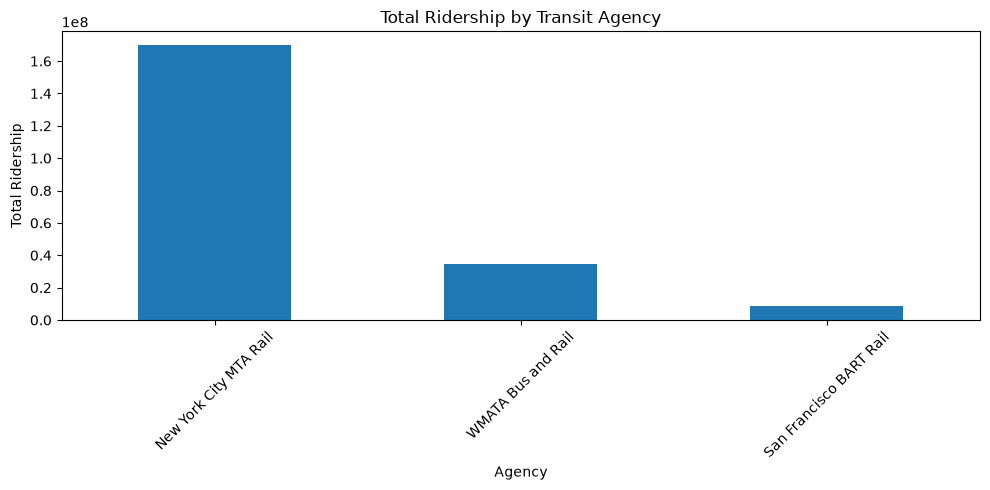

In [108]:
plt.figure(figsize=(10,5))

agency_totals.plot(kind="bar")

plt.title("Total Ridership by Transit Agency")
plt.xlabel("Agency")
plt.ylabel("Total Ridership")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Ridership Trends Over Time

This section examines how ridership changes throughout the observation period for each transit agency.

## Observation

New York City MTA Rail recorded the highest total ridership among the analyzed agencies, with substantially higher ridership compared to WMATA Bus and Rail and San Francisco BART Rail.

This difference likely reflects variations in population density, service coverage, and reliance on public transportation across metropolitan regions.

In [109]:
df = df.sort_values("date")

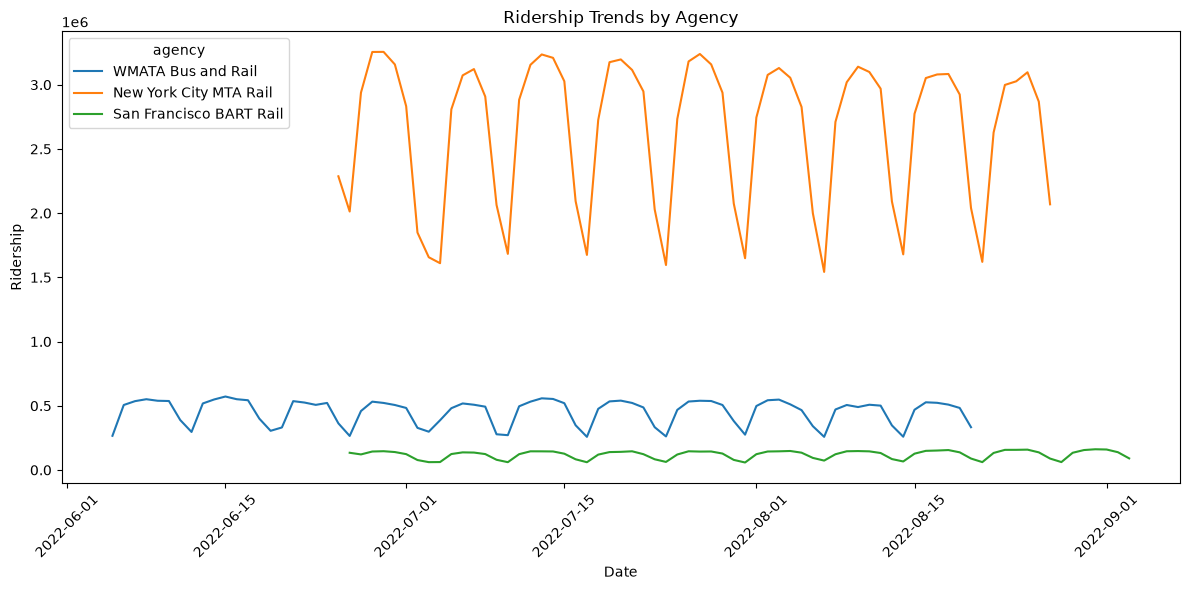

In [110]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="date",
    y="current_ridership",
    hue="agency"
)

plt.title("Ridership Trends by Agency")
plt.xlabel("Date")
plt.ylabel("Ridership")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Conclusions

Initial analysis shows differences in ridership levels between major transit agencies.

New York City MTA Rail recorded the highest total ridership among the agencies analyzed.

Further investigation could explore:
- seasonal ridership changes
- weekly patterns
- agency-specific trends
- relationships between transit characteristics and ridership

## Weekly Ridership Patterns

This section examines whether ridership changes depending on the day of the week.

Public transportation usage often varies between weekdays and weekends due to commuting patterns.

In [111]:
df["day_of_week"] = df["date"].dt.day_name()

In [112]:
df.head()

,agency,mode,date,week_number,current_ridership,year,day_of_week
0,WMATA Bus and Rail,Transit,2022-06-05,24,266000,2022,Sunday
1,WMATA Bus and Rail,Transit,2022-06-06,24,506000,2022,Monday
2,WMATA Bus and Rail,Transit,2022-06-07,24,536000,2022,Tuesday
3,WMATA Bus and Rail,Transit,2022-06-08,24,551000,2022,Wednesday
4,WMATA Bus and Rail,Transit,2022-06-09,24,539000,2022,Thursday


In [113]:
weekday_ridership = (
    df.groupby("day_of_week")["current_ridership"]
    .mean()
    .sort_values(ascending=False)
)

weekday_ridership

day_of_week
Wednesday    1.191315e+06
Thursday     1.177433e+06
Tuesday      1.166001e+06
Friday       1.102950e+06
Monday       1.000401e+06
Saturday     8.156573e+05
Sunday       6.275083e+05
Name: current_ridership, dtype: float64

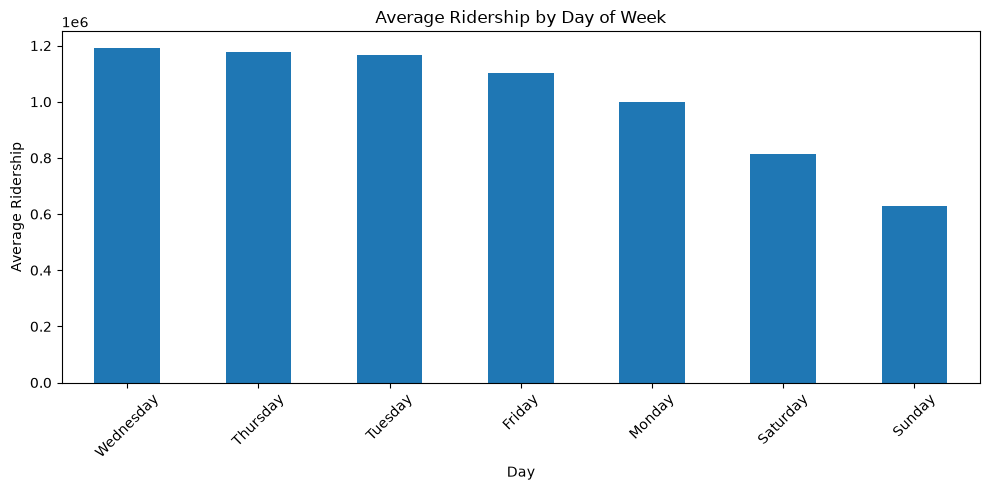

In [114]:
plt.figure(figsize=(10,5))

weekday_ridership.plot(kind="bar")

plt.title("Average Ridership by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Ridership")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Observation

Average ridership varies significantly depending on the day of the week.

Tuesday through Thursday show the highest average ridership, while Saturday and Sunday have substantially lower ridership. This suggests that transit usage is strongly influenced by weekday commuting patterns, with reduced demand during weekends.

## Weekly Patterns by Agency

This section compares weekday ridership patterns between individual transit agencies.

In [115]:
agency_weekday = (
    df.groupby(["agency", "day_of_week"])["current_ridership"]
    .mean()
    .reset_index()
)

agency_weekday.head()

,agency,day_of_week,current_ridership
0,New York City MTA Rail,Friday,2.915906e+06
1,New York City MTA Rail,Monday,2.638720e+06
2,New York City MTA Rail,Saturday,2.059614e+06
3,New York City MTA Rail,Sunday,1.679429e+06
4,New York City MTA Rail,Thursday,3.121980e+06


In [116]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

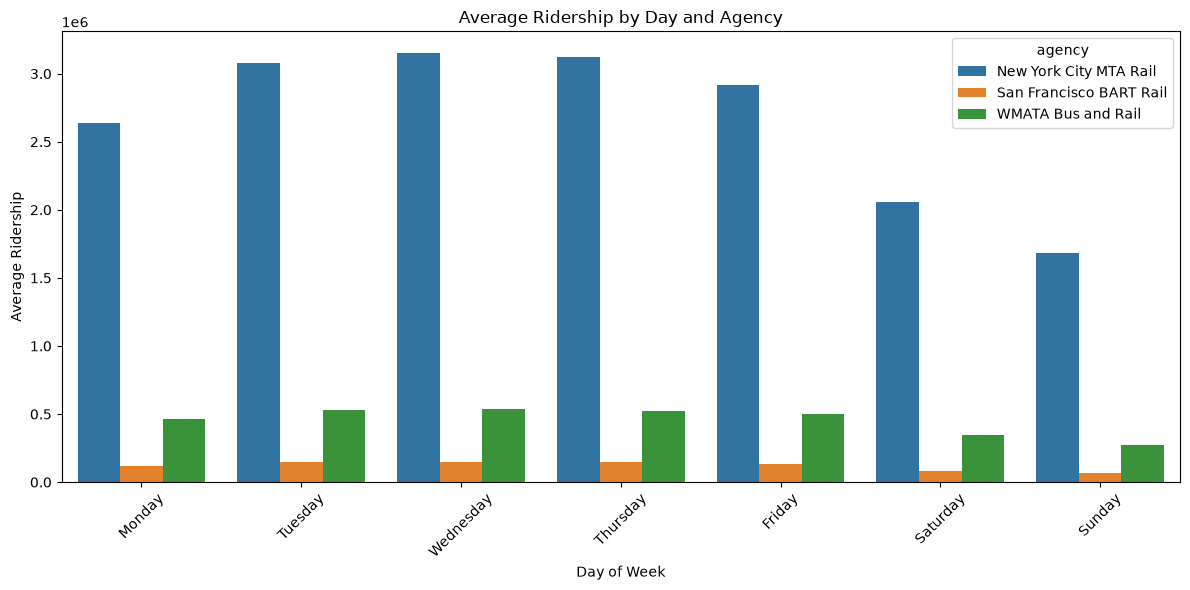

In [117]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=agency_weekday,
    x="day_of_week",
    y="current_ridership",
    hue="agency",
    order=day_order
)

plt.title("Average Ridership by Day and Agency")
plt.xlabel("Day of Week")
plt.ylabel("Average Ridership")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Observation

Ridership patterns remain consistent across all three transit agencies.

New York City MTA Rail maintains the highest average ridership throughout the week, while WMATA Bus and Rail and San Francisco BART Rail follow similar weekday and weekend trends at lower volumes.

All agencies experience increased ridership during the middle of the work week and reduced ridership during weekends, suggesting that public transportation usage is strongly affected by commuting patterns.

# Ridership Variability Analysis

This section examines differences in ridership consistency between transit agencies.

Measures such as mean, standard deviation, and range are used to understand how much ridership fluctuates over time.

In [118]:
ridership_stats = (
    df.groupby("agency")["current_ridership"]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("mean", ascending=False)
)

ridership_stats

,mean,median,std,min,max
agency,,,,,
New York City MTA Rail,2.654728e+06,2915908.0,567665.160141,1542464,3256053
WMATA Bus and Rail,4.534935e+05,501000.0,99601.392848,258000,572000
San Francisco BART Rail,1.204573e+05,133252.0,32018.180768,58169,161236


## Ridership Distribution

A box plot is used to visualize the spread of ridership values and identify differences in variability between agencies.

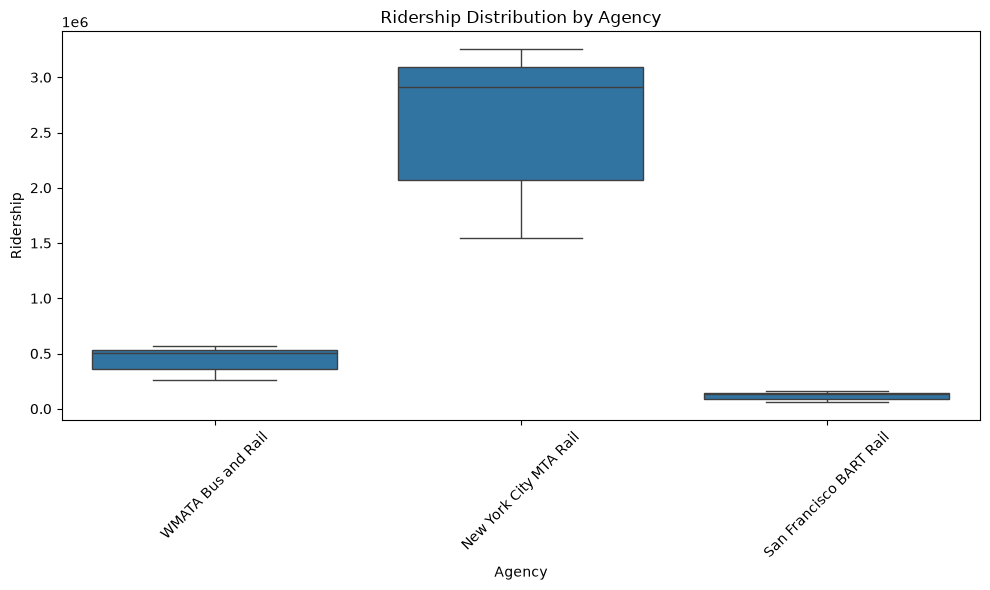

In [119]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="agency",
    y="current_ridership"
)

plt.title("Ridership Distribution by Agency")
plt.xlabel("Agency")
plt.ylabel("Ridership")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Observation

The distribution analysis shows substantial differences in ridership scale and variability between agencies.

New York City MTA Rail has both the highest ridership levels and the largest variation between daily observations. WMATA Bus and Rail demonstrates a more consistent ridership range, while San Francisco BART Rail operates at a significantly lower ridership scale compared to the other agencies.

The differences highlight how transit systems can vary in both overall demand and daily usage patterns.

# Relative Ridership Variability

Since agencies operate at different scales, ridership changes are normalized to compare patterns independent of total ridership volume.

In [120]:
df["normalized_ridership"] = (
    df.groupby("agency")["current_ridership"]
    .transform(lambda x: x / x.mean())
)

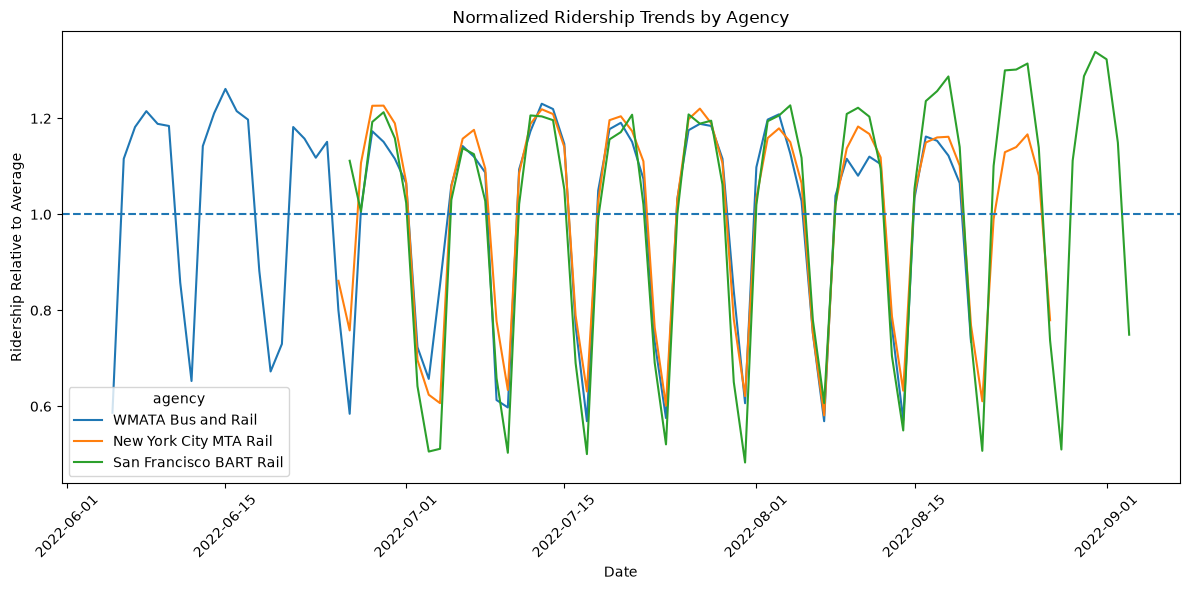

In [121]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="date",
    y="normalized_ridership",
    hue="agency"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.title("Normalized Ridership Trends by Agency")
plt.xlabel("Date")
plt.ylabel("Ridership Relative to Average")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Final Conclusions

## Summary

This project analyzed public transportation ridership data from three major transit agencies:

- New York City MTA Rail
- WMATA Bus and Rail
- San Francisco BART Rail

The dataset was cleaned, transformed, and analyzed using Python, Pandas, and visualization libraries.

## Key Findings

### 1. Ridership Differences Between Agencies

New York City MTA Rail recorded the highest total ridership among the analyzed agencies, significantly exceeding WMATA Bus and Rail and San Francisco BART Rail.

This difference reflects variations in population density, transit coverage, and regional transportation demand.

### 2. Weekly Ridership Patterns

All agencies demonstrated similar weekly trends, with higher ridership occurring during weekdays and reduced ridership during weekends.

The pattern suggests that commuting behavior is a major factor influencing transit usage.

### 3. Ridership Variability

Statistical analysis showed that agencies differ not only in ridership volume but also in daily variability.

New York City MTA Rail experienced the largest fluctuations due to its larger ridership scale, while smaller agencies showed more consistent daily patterns.

### 4. Normalized Ridership Analysis

After adjusting ridership relative to each agency's average, similar seasonal patterns were observed across transit systems.

This indicates that while agencies differ greatly in size, they share comparable behavioral trends.

## Future Improvements

Additional analysis could include:

- Incorporating weather data
- Comparing ridership before and after major events
- Building forecasting models
- Applying machine learning methods to predict future ridership

In [123]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/transit_ridership_cleaned.csv",
    index=False
)